# Pseudocount analysis

Layout the problem with deconvolving low occupancy bins in the chromatin clearly. And brainstorm possibly, elegant solutions.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [164]:
from src.chromatin_model import ChromatinModel
from src.config import load_default_chrom_configs

config1, config2 = load_default_chrom_configs('distinct')

chromatin_model1 = ChromatinModel(config1)

todo: Loading testing config from replication deconvolution


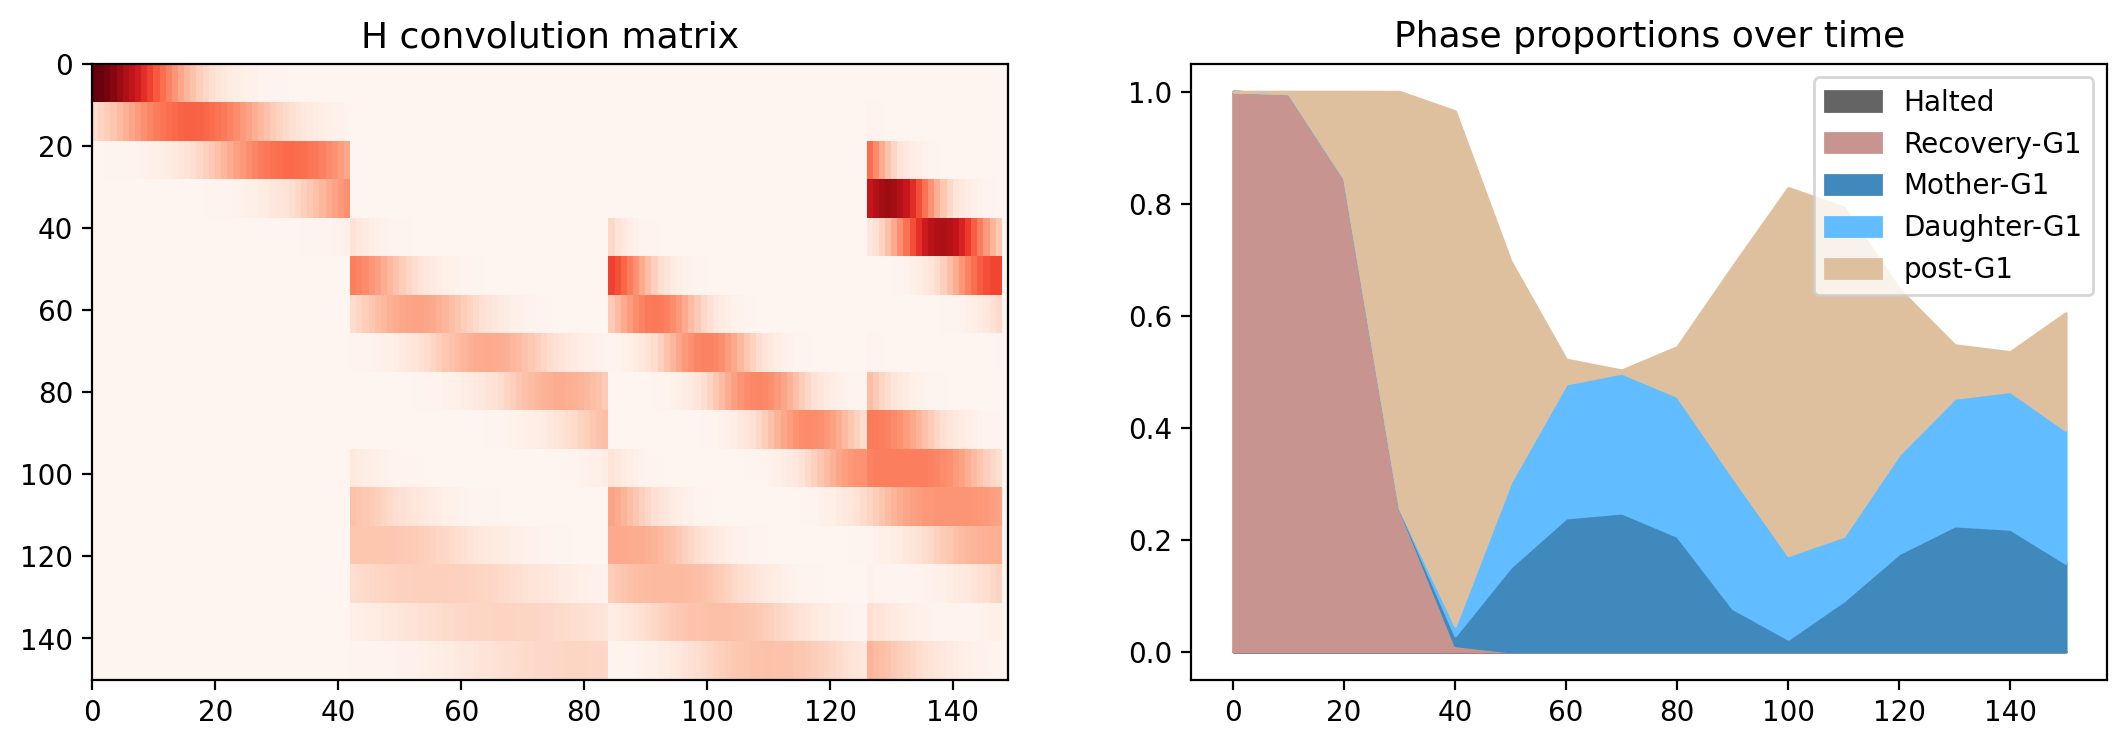

In [165]:
config1.plot_H()

In [3]:
mnase_span = 758500, 759500
chromatin_model1.load_mnase_span(chrom=14, mnase_span=mnase_span)

Loading chromosome reads: 14
Applying a normalization for length distribution


In [4]:
from src.chromatin_deconvolution_solver import example_N_frep_b

padding_type = 'both'
N, f_rep, b = example_N_frep_b(config1)


In [6]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep,
    padding_type='both', subsample=5)

Subsampling to top 5 sites
Indices with the highest max value:  [1734 1972 1754 1773 1773 1773 1816 1734 1972 1754 1773 1773 1653 1671
 1570 1773]


In [43]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.00001,
                                             gamma_max=0.0001)

	Base error (γ=0):	rn: 0.018333	sn: 223.612298
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0192491
			Absolute (e0 + 0.04): 0.0583325
			Chosen: 0.019249
		Right:
			Relative (1.40 * e0): 0.0256655
			Absolute (e0 + 0.32): 0.338333
			Chosen: 0.338333
	Searching for left boundary gamma...
		γ: 5.5e-05	rn: 0.0269	sn: 1.4502
		γ: 3.25e-05	rn: 0.0256	sn: 1.6538
		γ: 2.125e-05	rn: 0.0241	sn: 2.0416
		γ: 1.5625e-05	rn: 0.0233	sn: 2.2978
		γ: 1.28125e-05	rn: 0.0230	sn: 2.4495
		γ: 1.14062e-05	rn: 0.0228	sn: 2.5460
		γ: 1.07031e-05	rn: 0.0227	sn: 2.6334
	Left boundary gamma found: 1.03516e-05
	Searching for right boundary gamma...
		γ: 5.51758e-05	rn: 0.0269	sn: 1.4490
		γ: 7.75879e-05	rn: 0.0286	sn: 1.2890
		γ: 8.87939e-05	rn: 0.0299	sn: 1.1882
		γ: 9.4397e-05	rn: 0.0303	sn: 1.1653
		γ: 9.71985e-05	rn: 0.0305	sn: 1.1536
		γ: 9.85992e-05	rn: 0.0307	sn: 1.1465
		γ: 9.92996e-05	rn: 0.0307	sn: 1.1433
	Right boundary gamma found: 9.96498e-05
Finding elbow in the curve, selecting 20 bins

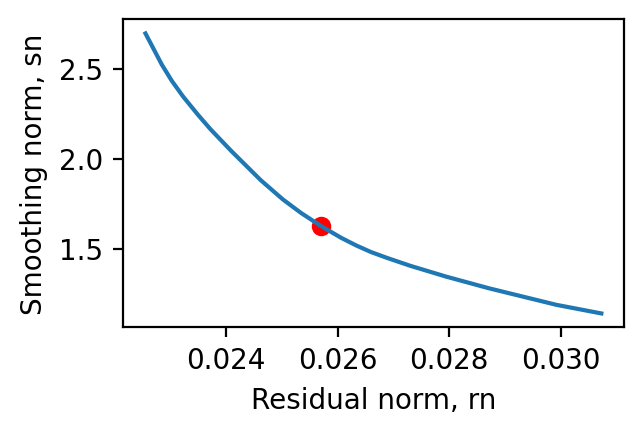

In [44]:
chrom_find_gamma.find_optimal_gamma()

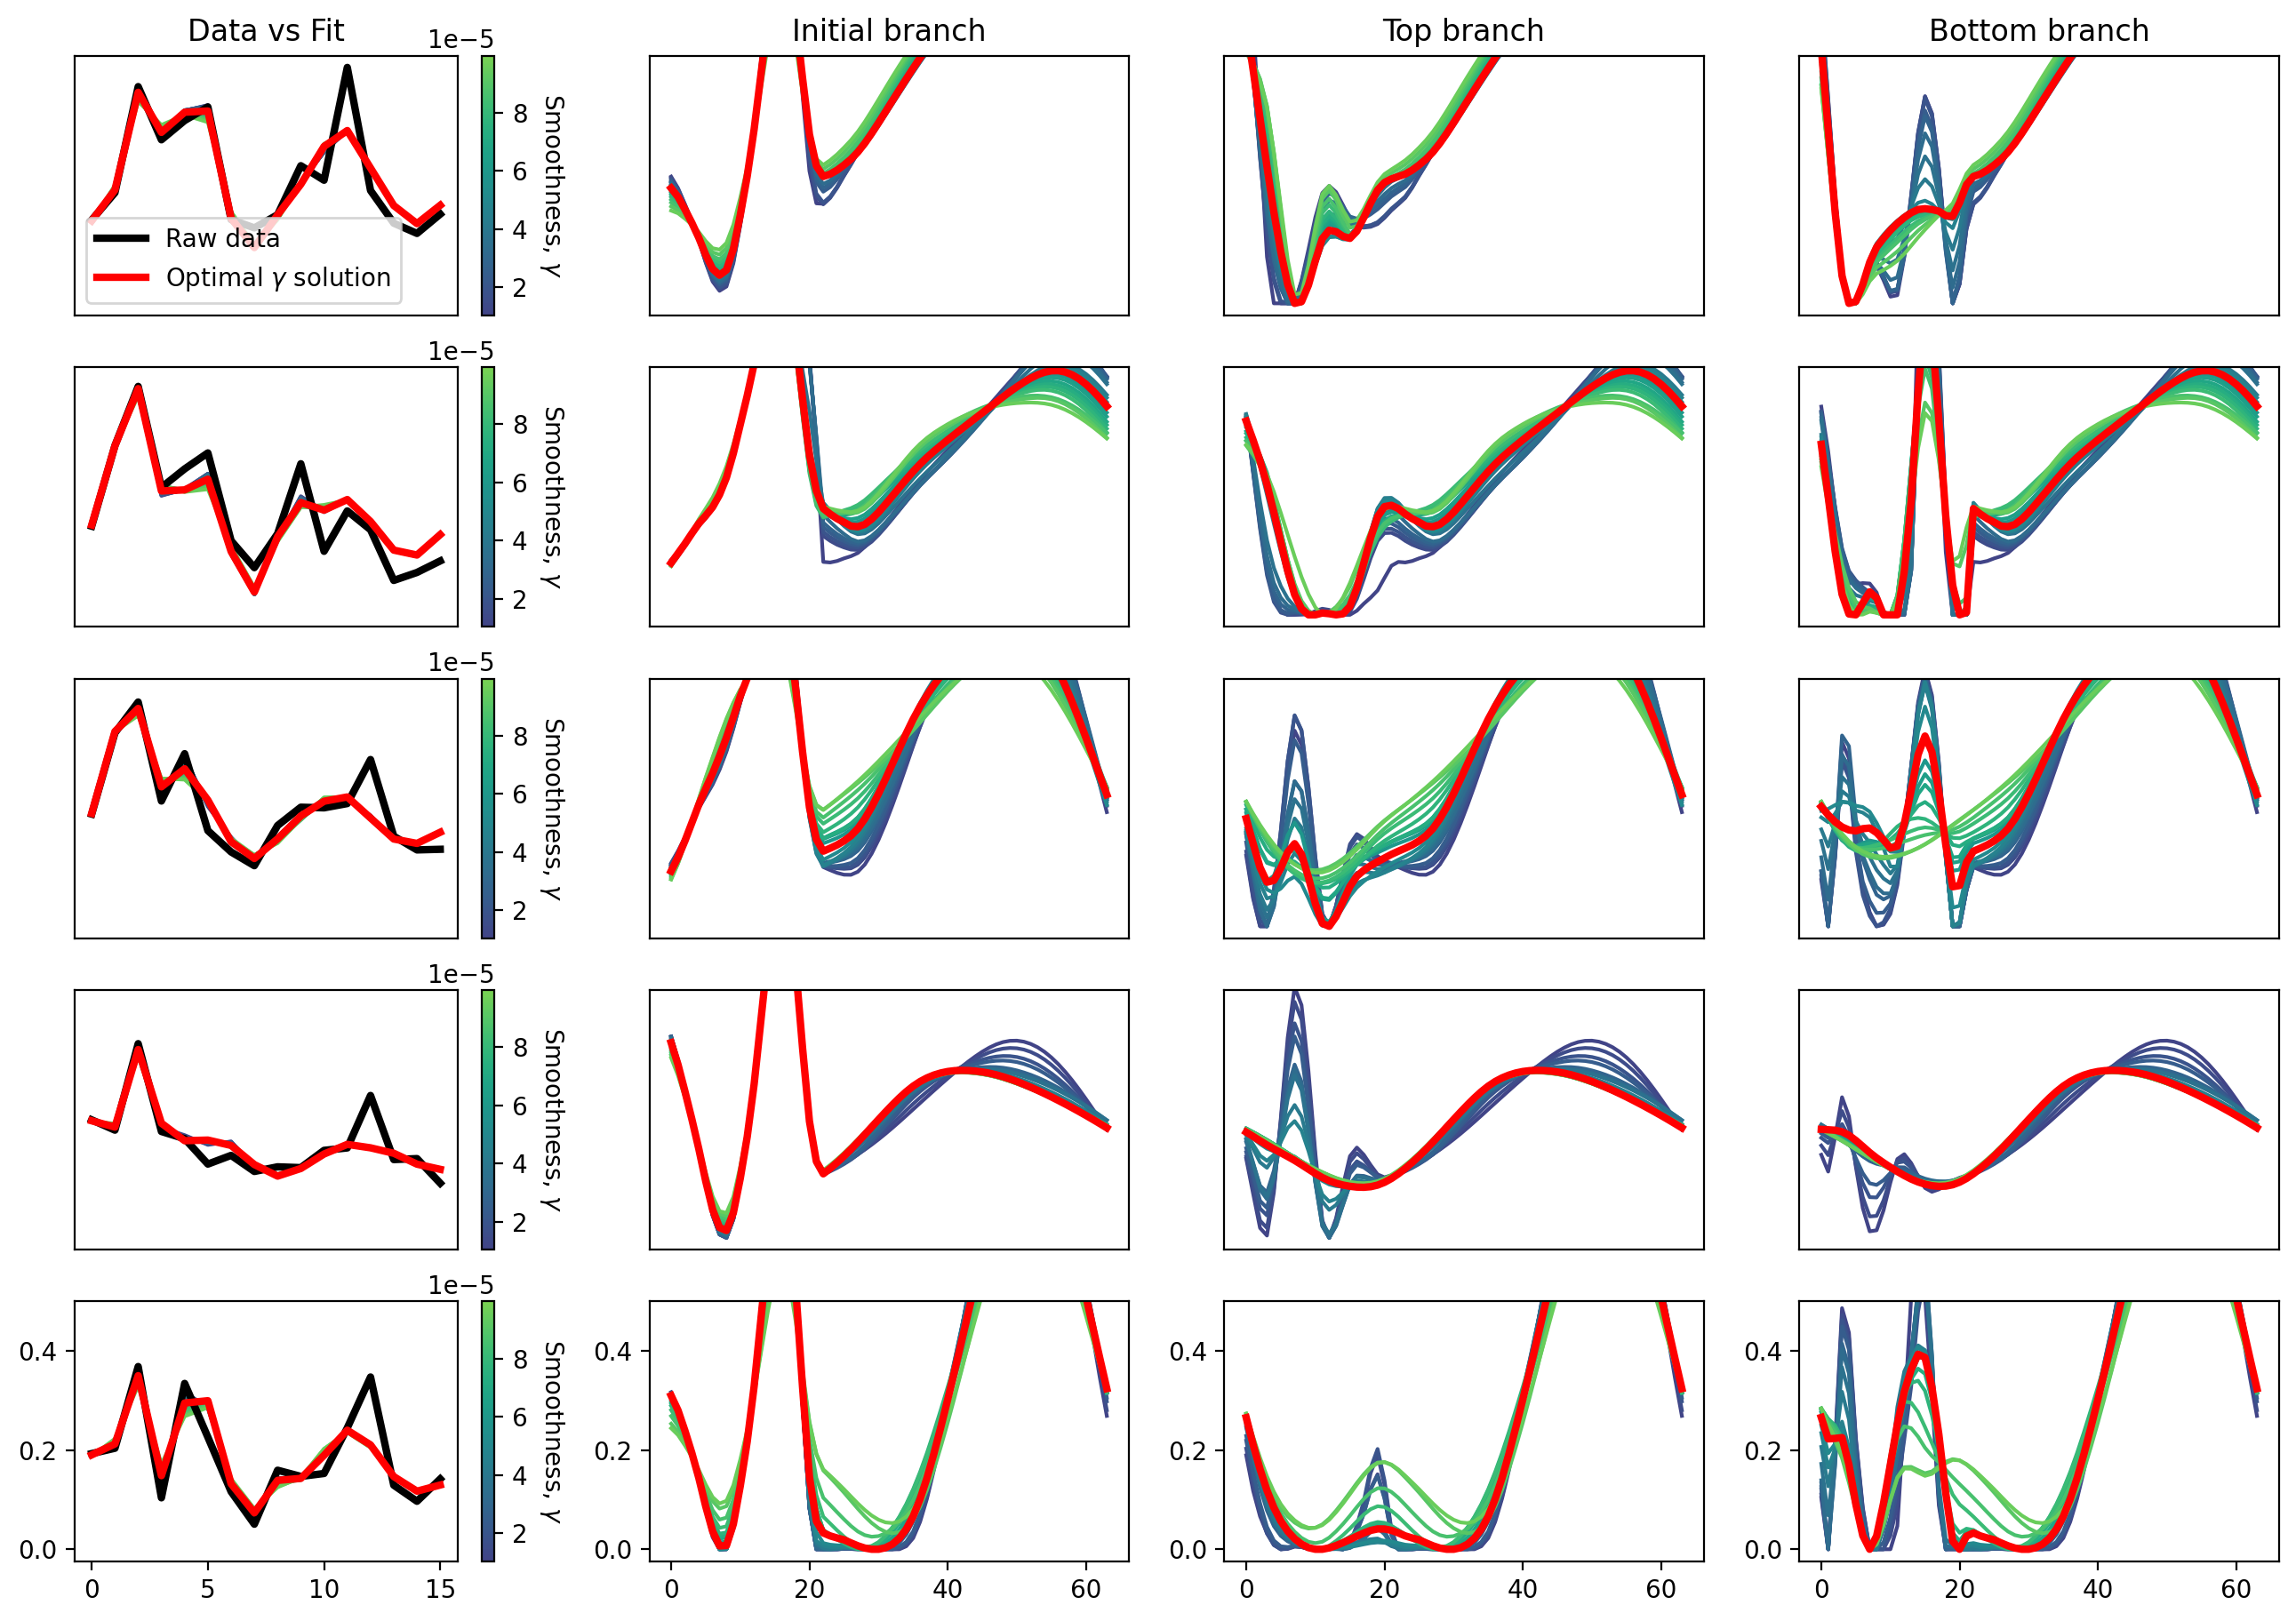

In [45]:
gamma_predicted_Gs_test = chrom_find_gamma.plot_gamma_sweep()

In [63]:
chromatin_solver_full = ChromatinDeconvolveSolver(config1, 
    chromatin_model1.G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver_full.deconvolve_G_iteratively(
   gamma=2e-4)


0/2600 - 00:00:00.001
500/2600 - 00:00:04.029
1000/2600 - 00:00:41.706
1500/2600 - 00:01:23.053
2000/2600 - 00:02:01.057
2500/2600 - 00:02:36.210


In [247]:
from src.chromatin_model import plot_prediction

plot_prediction(chromatin_model, N, full_deconvolved_F, f_rep, b)


ValueError: cannot reshape array of size 80 into shape (16,26,newaxis)

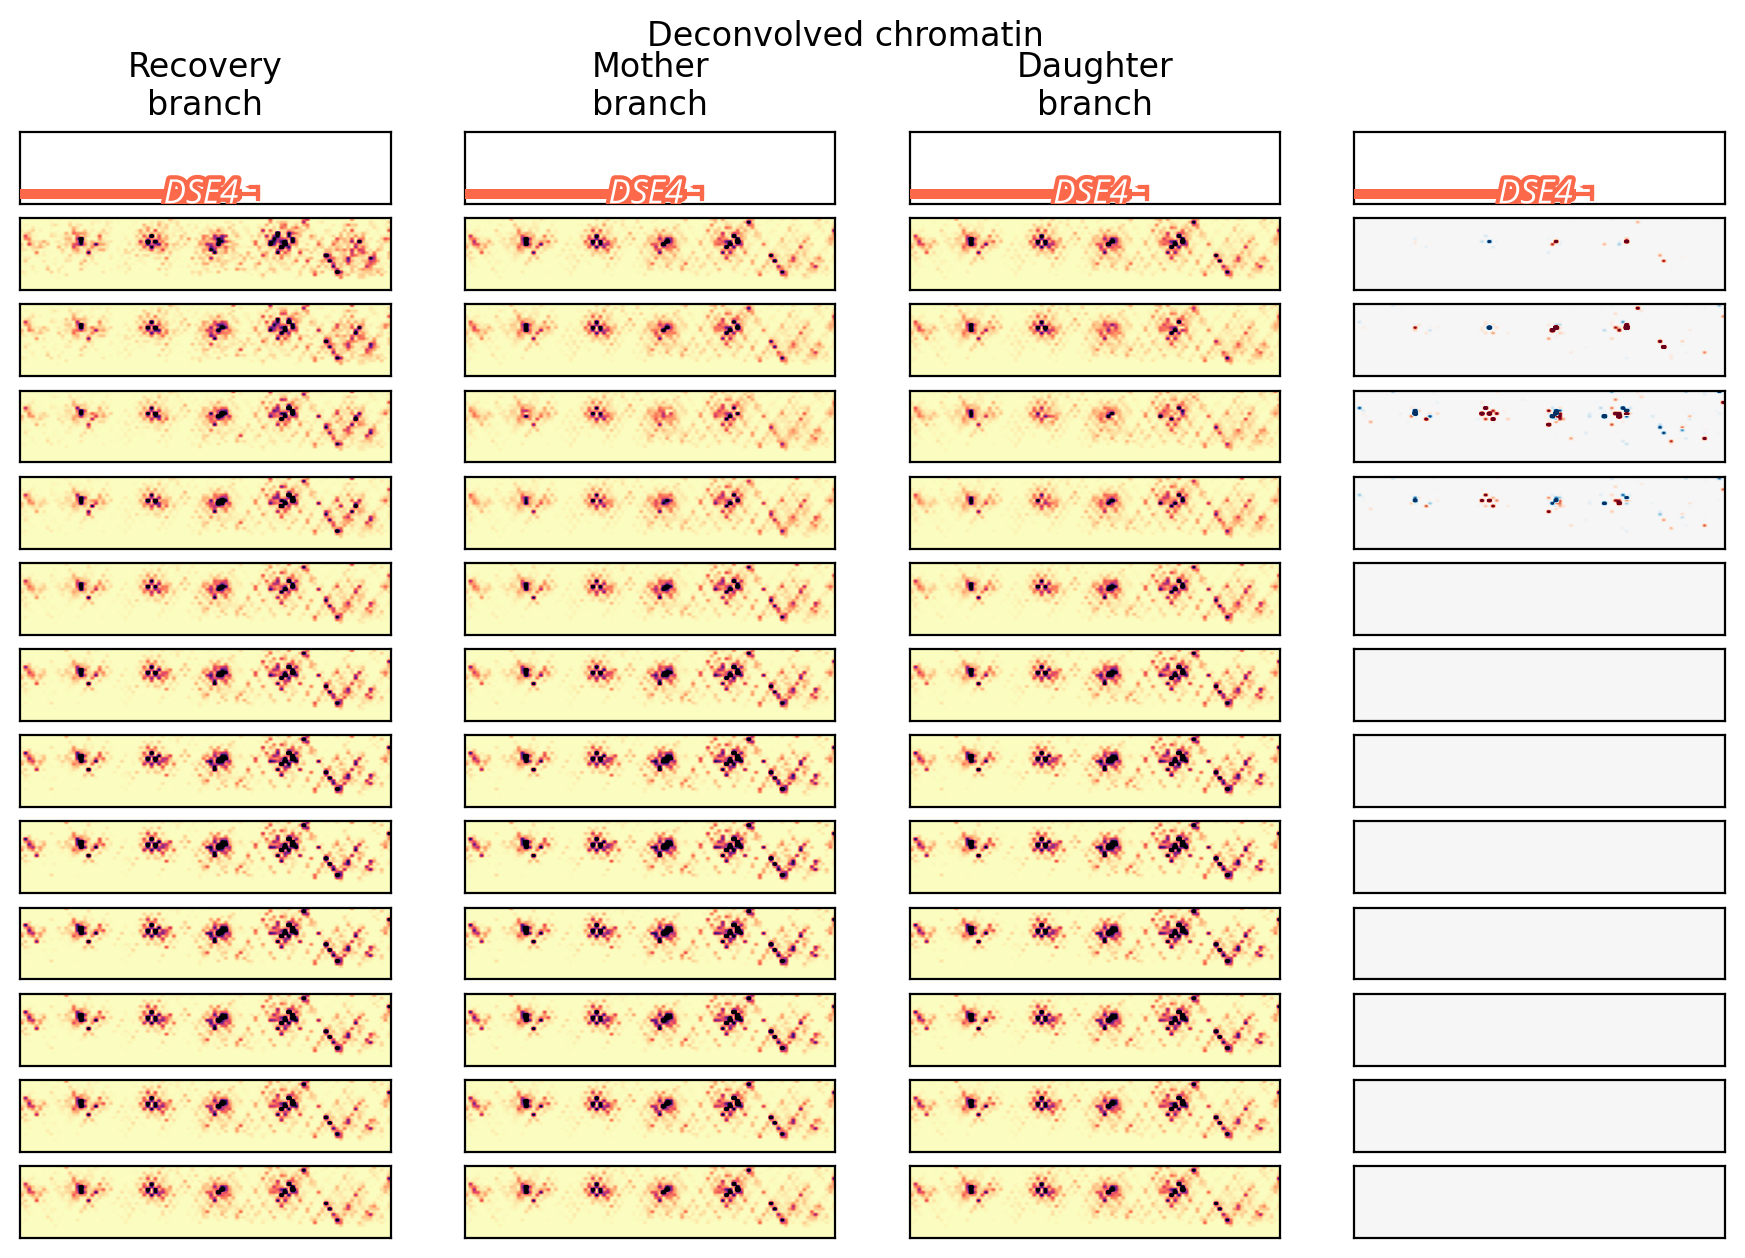

In [104]:
plot_branches(chromatin_model1, full_deconvolved_F)

In [278]:
from src.chromatin_deconvolution_solver import plot_example_fits
from src.chromatin_deconvolution_solver import plot_branches
from src.chromatin_model import plot_prediction
from src.geneset import get_deconvolved_geneset
from src.sgd import get_orfname

def deconvolve_and_plot(gene_name, output_directory):
    genes = get_deconvolved_geneset()

    orfname = get_orfname(gene_name)

    gene = genes.loc[orfname]
    tss = gene.TSS
    chrom = gene.chr
    mnase_span = tss-1200, tss+1200

    chromatin_model = ChromatinModel(config1)
    chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

    chromatin_solver = ChromatinDeconvolveSolver(config1, 
        chromatin_model.G, N, b, f_rep, padding_type=padding_type)
    full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=2e-4)
    np.save(f"{output_directory}/{gene_name}_F.npy", full_deconvolved_F)

    fig = plot_branches(chromatin_model, full_deconvolved_F)
    plt.savefig(f"{output_directory}/{gene_name}_branches.png")
    plt.close(fig)

    fig = plot_prediction(chromatin_model, N, full_deconvolved_F, f_rep, b)
    plt.savefig(f"{output_directory}/{gene_name}_prediction.png")
    plt.close(fig)

    fig = plot_example_fits(chromatin_solver)
    plt.savefig(f"{output_directory}/{gene_name}_curves.png")
    plt.close(fig)

In [282]:
from src.utils import mkdir_safe

output_directory = 'output/daughter_specific_chromatin_sweep_kappa5e-3'
mkdir_safe(output_directory)


Creating directory: output/daughter_specific_chromatin_sweep_kappa5e-3...Directory exists. Skipping.


In [283]:
from src.geneset import cyclin_genes, positive_control_genes
from src.timer import Timer

more_genes = ['SIC1', 'CLB2', 'SSK22', 'PCL1', 'DSE1', 'MCM2', 
    'MCM3', 'MCM4', 'MCM5', 'MCM6', 'MCM7', 'CDC6', 'DBF4', 
    'CDC7', 'CDC45', 'SLD2', 'SLD5', 'PSF1', 'PSF3', 'HTA1', 'HTA2', 
    'HTB1', 'HTB2', 'HHT1', 'HHT2', 'HHF1', 'HHF2', 'HHO1', 'HTZ1']

gene_names = more_genes#cyclin_genes() + positive_control_genes() + more_genes

timer = Timer()

for gene_name in gene_names:  
    print(gene_name)
    deconvolve_and_plot(gene_name, output_directory)

    timer.print_time()


SIC1
Loading chromosome reads: 12
Applying a normalization for length distribution
0/6240 - 00:00:00.008
500/6240 - 00:00:00.011
1000/6240 - 00:00:02.681
1500/6240 - 00:00:30.767
2000/6240 - 00:01:10.451
2500/6240 - 00:02:02.436
3000/6240 - 00:02:47.098
3500/6240 - 00:03:35.890
4000/6240 - 00:04:27.868
4500/6240 - 00:05:13.484
5000/6240 - 00:06:08.339
5500/6240 - 00:06:52.484
6000/6240 - 00:07:38.876
00:08:26.823
CLB2
Loading chromosome reads: 16
Applying a normalization for length distribution
0/6240 - 00:00:00.002
500/6240 - 00:00:00.004
1000/6240 - 00:00:02.621
1500/6240 - 00:00:32.314
2000/6240 - 00:01:33.153
2500/6240 - 00:02:19.525
3000/6240 - 00:03:01.766
3500/6240 - 00:03:49.366
4000/6240 - 00:04:34.791
4500/6240 - 00:05:20.759
5000/6240 - 00:06:08.493
5500/6240 - 00:06:51.312
6000/6240 - 00:07:41.093
00:16:35.709
SSK22
Loading chromosome reads: 3
Applying a normalization for length distribution
0/6240 - 00:00:00.002
500/6240 - 00:00:00.005
1000/6240 - 00:00:04.689
1500/6240 - 

4000/6240 - 00:04:24.318
4500/6240 - 00:05:16.772
5000/6240 - 00:06:02.126
5500/6240 - 00:06:47.828
6000/6240 - 00:07:35.413
02:35:03.867
HTA2
Loading chromosome reads: 2
Applying a normalization for length distribution
0/6240 - 00:00:00.000
500/6240 - 00:00:00.002
1000/6240 - 00:00:02.665
1500/6240 - 00:00:31.855
2000/6240 - 00:01:19.585
2500/6240 - 00:02:04.359
3000/6240 - 00:02:54.792
3500/6240 - 00:03:45.052
4000/6240 - 00:04:29.714
4500/6240 - 00:05:22.541
5000/6240 - 00:06:07.857
5500/6240 - 00:06:54.383
6000/6240 - 00:07:40.785
02:43:03.434
HTB1
Loading chromosome reads: 4
Applying a normalization for length distribution
0/6240 - 00:00:00.003
500/6240 - 00:00:00.007
1000/6240 - 00:00:04.177
1500/6240 - 00:00:36.287
2000/6240 - 00:01:25.953
2500/6240 - 00:02:09.886
3000/6240 - 00:02:58.643
3500/6240 - 00:03:45.485
4000/6240 - 00:04:31.531
4500/6240 - 00:05:24.613
5000/6240 - 00:06:10.846
5500/6240 - 00:07:00.694
6000/6240 - 00:07:45.039
02:51:23.521
HTB2
Loading chromosome reads:

In [167]:
from src.sgd import get_orfname
from src.sgd import read_nondubious_genes_dataset

genes = read_nondubious_genes_dataset()
# Let's look at SSK22 and examine whether we can tune the smoothing of the top and bottom 
# branches to an equal level of variability....and understand the reasoning behind
# the differences in variability.

orfname = get_orfname('SSK22')

gene = genes.loc[orfname]
tss = gene.TSS
chrom = gene.chr
mnase_span = tss-200, tss+200

chromatin_model = ChromatinModel(config1)
chromatin_model.load_mnase_span(chrom=chrom, mnase_span=mnase_span)

Loading chromosome reads: 3
Applying a normalization for length distribution


In [ ]:
from src.deconvolution_solver import compute_branch_lengths

compute_branch_lengths(config1)

In [168]:
from src.chromatin_gamma_search import ChromatinFindOptimalGamma
from src.chromatin_deconvolution_solver import ChromatinDeconvolveSolver

In [169]:
from src.chromatin_deconvolution_solver import example_N_frep_b

padding_type = 'both'
N, f_rep, b = example_N_frep_b(config1)


In [170]:
# chromatin_solver = ChromatinDeconvolveSolver(config1, 
#     chromatin_model.G, N, b, f_rep, padding_type=padding_type)
# full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=0.00088)

In [171]:
# plot_branches(chromatin_model, full_deconvolved_F)


In [204]:
num_examples = 5
G_max_df = pd.DataFrame({'max_value': chromatin_model.G.max(axis=0), 
    'index': np.arange(chromatin_model.G.shape[1])})
highest_Gs = G_max_df.sort_values('max_value', 
    ascending=False).head(num_examples)['index'].values
G_values = chromatin_model.G[:, highest_Gs].copy()

In [242]:
scale = 1
example_G = G_values*scale

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    example_G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=1e-4*scale)

0/5 - 00:00:00.302


In [243]:
cg1_tps = config1.get_timepoints_for_phase('CG1')
postg1_tps = config1.get_timepoints_for_phase('postG1')
post_g1_indices = config1.get_Hpositions_for_phase('postG1')

len_cg1_tps = cg1_tps[-1]-cg1_tps[0]
len_postg1_tps = postg1_tps[-1]-postg1_tps[0]

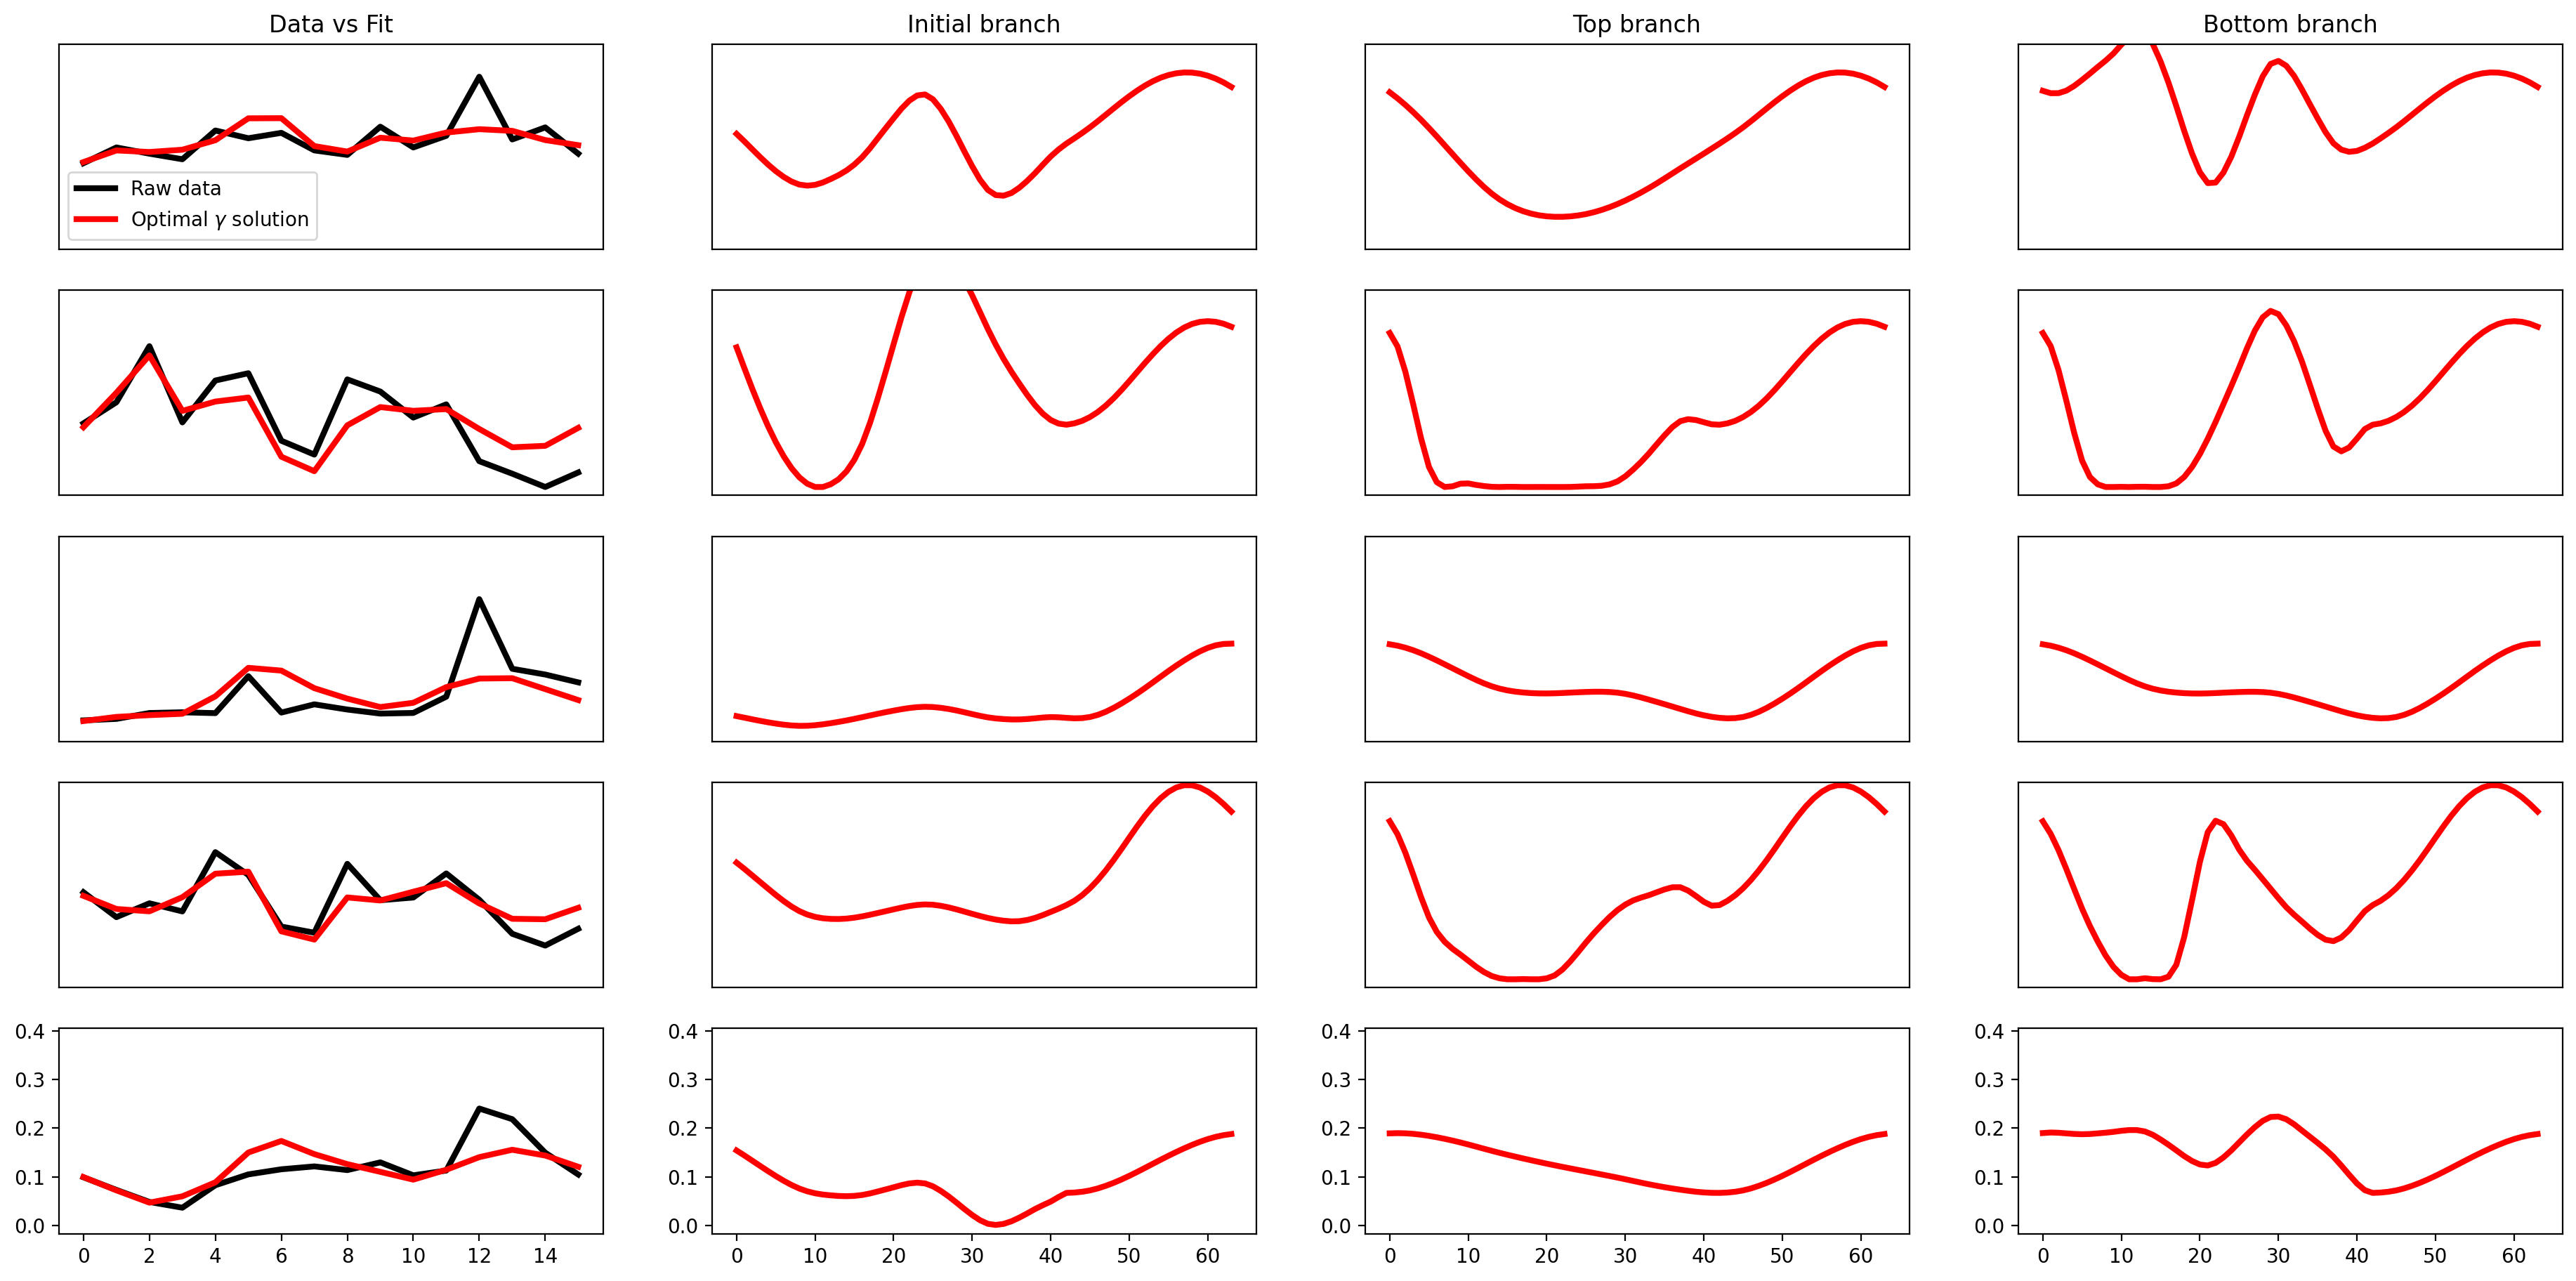

In [244]:
from src.chromatin_deconvolution_solver import plot_example_fits
plot_example_fits(chromatin_solver)

In [256]:
i = 3

num_examples = 5
G_max_df = pd.DataFrame({'max_value': chromatin_model.G.max(axis=0), 
    'index': np.arange(chromatin_model.G.shape[1])})
highest_Gs = G_max_df.sort_values('max_value', 
    ascending=False).head(num_examples)['index'].values
#G_values = chromatin_model.G[:, highest_Gs[i]:highest_Gs[i]+1].copy()
G_values = chromatin_model.G[:, highest_Gs].copy()

In [266]:
scale = 1
example_G = G_values*scale

chromatin_solver = ChromatinDeconvolveSolver(config1, 
    example_G, N, b, f_rep, padding_type=padding_type)
full_deconvolved_F = chromatin_solver.deconvolve_G_iteratively(gamma=1e-4*scale)

0/5 - 00:00:00.323


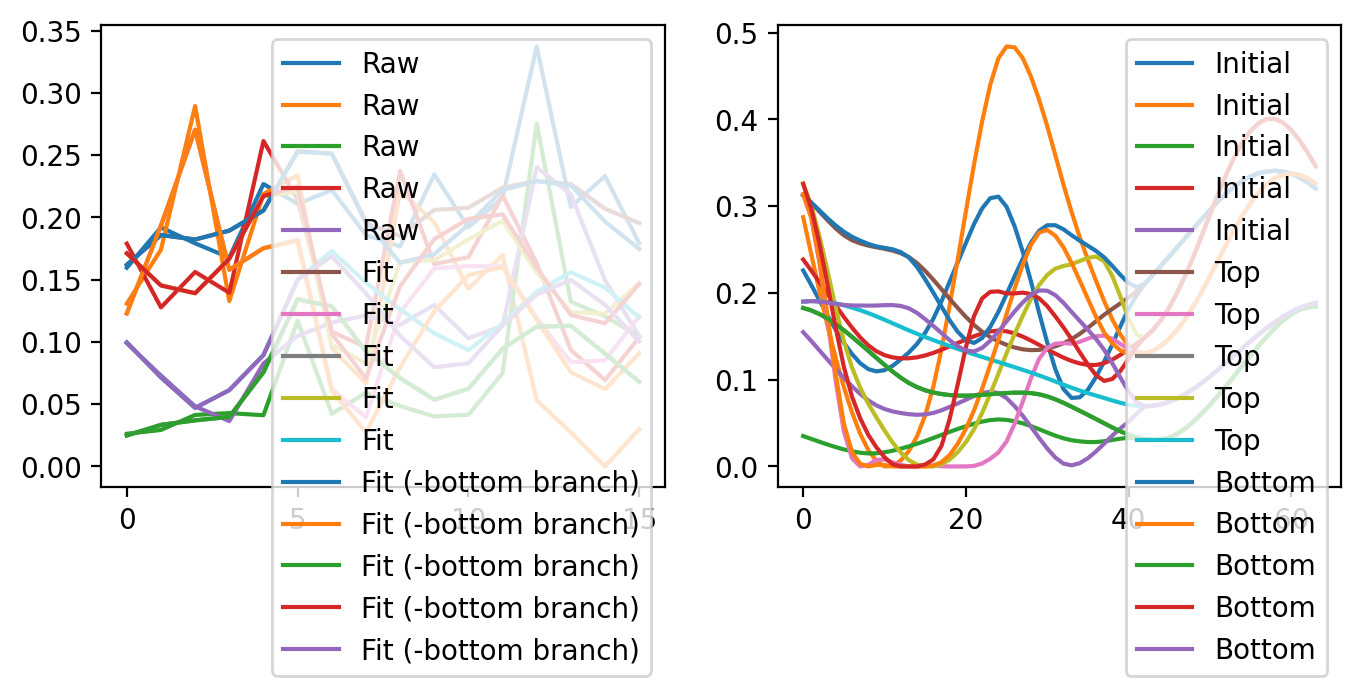

In [267]:
rg1_indices = config1.get_Hpositions_for_phase('RG1')
cg1_indices = config1.get_Hpositions_for_phase('CG1')
dg1_indices = config1.get_Hpositions_for_phase('DG1')

i_indices = config1.get_Hpositions_for_branch('i')
t_indices = config1.get_Hpositions_for_branch('t')
b_indices = config1.get_Hpositions_for_branch('b')

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.plot(example_G, label="Raw")


plt.plot(N@config1.H@full_deconvolved_F, label="Fit")

modified_F = full_deconvolved_F.copy()
modified_F[b_indices] = modified_F[t_indices]
plt.plot(N@config1.H@modified_F, label="Fit (-bottom branch)")

plt.legend()

plt.subplot(1, 2, 2)
plt.plot(full_deconvolved_F[i_indices], label="Initial")
plt.plot(full_deconvolved_F[t_indices], label="Top")
plt.plot(full_deconvolved_F[b_indices], label="Bottom")
plt.legend()

	Base error (γ=0):	rn: 0.023585	sn: 56.530761
	Error boundaries:
		Left:
			Relative (1.05 * e0): 0.0247645
			Absolute (e0 + 0.04): 0.0635852
			Chosen: 0.024764
		Right:
			Relative (1.40 * e0): 0.0330193
			Absolute (e0 + 0.32): 0.343585
			Chosen: 0.343585
	Searching for left boundary gamma...
		γ: 0.00055	rn: 0.0337	sn: 0.1757
		γ: 0.000325	rn: 0.0315	sn: 0.2137
		γ: 0.0002125	rn: 0.0302	sn: 0.2457
		γ: 0.00015625	rn: 0.0291	sn: 0.2854
		γ: 0.000128125	rn: 0.0284	sn: 0.3174
		γ: 0.000114063	rn: 0.0280	sn: 0.3410
		γ: 0.000107031	rn: 0.0278	sn: 0.3550
		γ: 0.000103516	rn: 0.0277	sn: 0.3608
		γ: 0.000101758	rn: 0.0276	sn: 0.3637
		γ: 0.000100879	rn: 0.0276	sn: 0.3651
	Left boundary gamma found: 0.000100439
	Searching for right boundary gamma...
		γ: 0.00055022	rn: 0.0337	sn: 0.1756
		γ: 0.00077511	rn: 0.0350	sn: 0.1621
		γ: 0.000887555	rn: 0.0356	sn: 0.1564
		γ: 0.000943777	rn: 0.0359	sn: 0.1540
		γ: 0.000971889	rn: 0.0361	sn: 0.1530
		γ: 0.000985944	rn: 0.0362	sn: 0.1522
		γ: 0.000

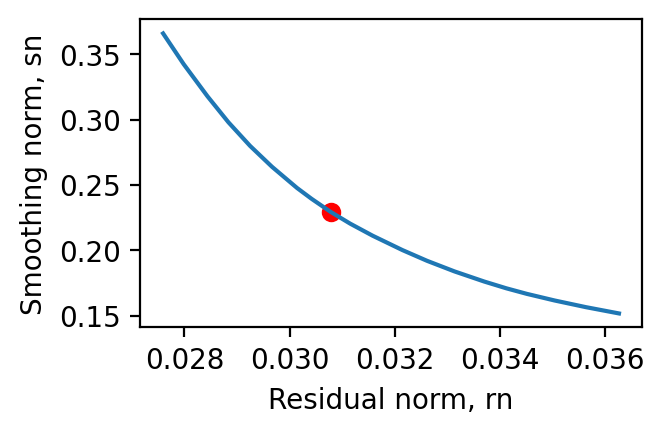

In [268]:
chrom_find_gamma = ChromatinFindOptimalGamma(chromatin_solver, gamma_min=0.0001,
                                             gamma_max=0.001)
chrom_find_gamma.find_optimal_gamma()

0

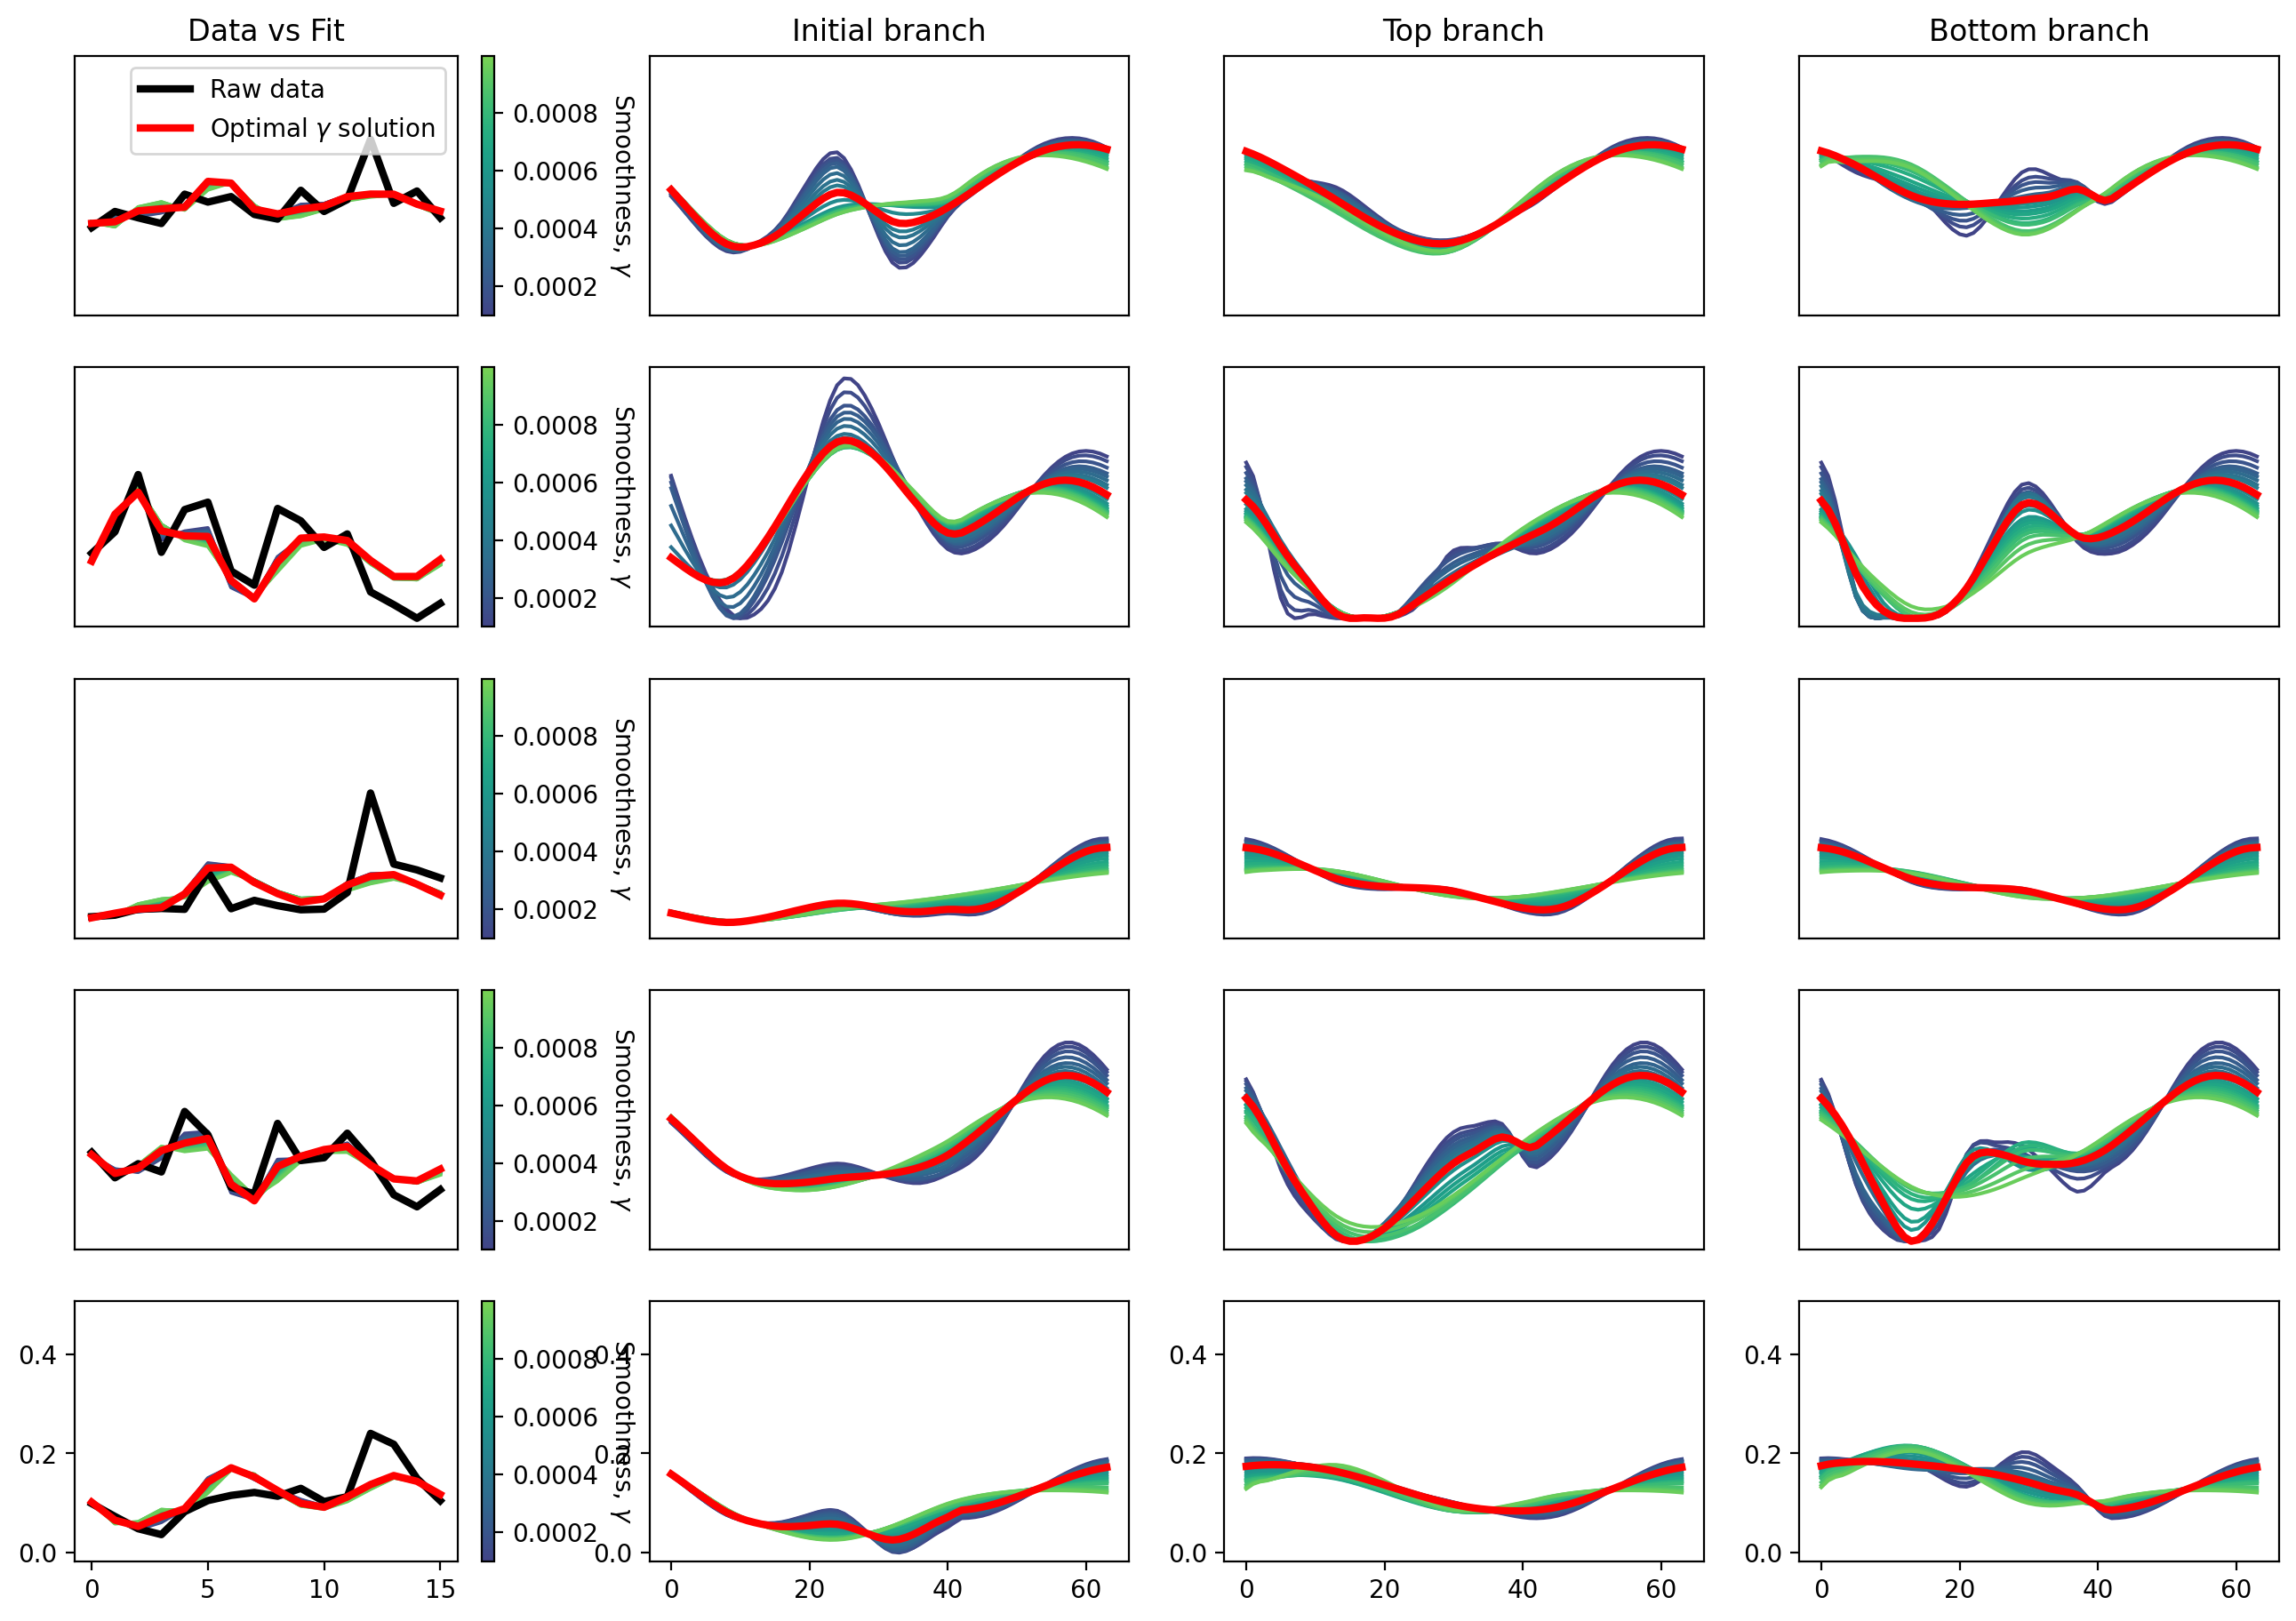

In [269]:
chrom_find_gamma.plot_gamma_sweep()
0